<a href="https://colab.research.google.com/github/lihkaw/BME450-project/blob/main/3_4CNN_BME_450_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BME 450 Final Project
Predicting Infant Emotion based on Crying Audio

In [ ]:
# Import necessary libaries
import os
import torch
import torchaudio
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchaudio import datasets, transforms
import matplotlib.pyplot as plt
from google.colab import drive

# Import dataset
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Transform dataset
class AudioFolder(Dataset):
    def __init__(self, root, sample_rate=22050, n_mels=64):
        self.root = root
        self.files = []
        self.classes = sorted(os.listdir(root))

        for i, cls in enumerate(self.classes):
            for filename in os.listdir(os.path.join(root, cls)):
              path = os.path.join(root, cls, filename)
              if os.path.isfile(path):
                self.files.append((path, i))

        self.transform = nn.Sequential(
            transforms.MelSpectrogram(sample_rate=sample_rate, n_mels=n_mels),
            transforms.AmplitudeToDB()
        )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
      path, label = self.files[idx]
      waveform, sr = torchaudio.load(path)
      waveform = waveform.mean(0, keepdim=True)

      spec = self.transform(waveform)

      # Pad or truncate to fixed time length
      target_len = 1024
      if spec.shape[2] < target_len:
          pad = target_len - spec.shape[2]
          spec = F.pad(spec, (0, pad))
      else:
          spec = spec[:, :, :target_len]

      return spec, label


Train_d = AudioFolder("/content/drive/MyDrive/BME 450/Project/datasets/train")
Test_d  = AudioFolder("/content/drive/MyDrive/BME 450/Project/datasets/test")

train_loader = DataLoader(Train_d, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(Test_d,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
class AudioCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.classifier(x)
        return x

In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        loss = loss_fn(model(X), y)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        loss, current = loss.item(), (batch + 1) * len(X)
        print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    size, num_batches = len(dataloader.dataset), len(dataloader)
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).sum().item()
    test_losses.append(test_loss / num_batches)
    test_accuracies.append(100 * correct / size)
    print(f"Test Error: \n Accuracy: {(100*correct/size):>0.1f}%, Avg loss: {test_loss/num_batches:>8f}\n")

# Storage
test_losses, test_accuracies = [], []

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AudioCNN(num_classes=len(Train_d.classes)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training
epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_loader, model, loss_fn, optimizer)
    test_loop(test_loader,   model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 1.795385  [   32/  558]
loss: 1.805925  [   64/  558]
loss: 1.743603  [   96/  558]
loss: 1.762312  [  128/  558]
loss: 1.875526  [  160/  558]
loss: 1.762629  [  192/  558]
loss: 1.740005  [  224/  558]
loss: 1.800484  [  256/  558]
loss: 1.716097  [  288/  558]
loss: 1.790975  [  320/  558]
loss: 1.786548  [  352/  558]
loss: 1.769821  [  384/  558]
loss: 1.746965  [  416/  558]
loss: 1.729305  [  448/  558]
loss: 1.748896  [  480/  558]
loss: 1.766687  [  512/  558]
loss: 1.841742  [  544/  558]
loss: 1.707421  [  252/  558]
Test Error: 
 Accuracy: 14.0%, Avg loss: 1.809587

Epoch 2
-------------------------------
loss: 1.712599  [   32/  558]
loss: 1.711970  [   64/  558]
loss: 1.779743  [   96/  558]
loss: 1.751582  [  128/  558]
loss: 1.721720  [  160/  558]
loss: 1.736615  [  192/  558]
loss: 1.769538  [  224/  558]
loss: 1.718419  [  256/  558]
loss: 1.746122  [  288/  558]
loss: 1.689499  [  320/  558]
loss: 1.765399  [  352/  558]

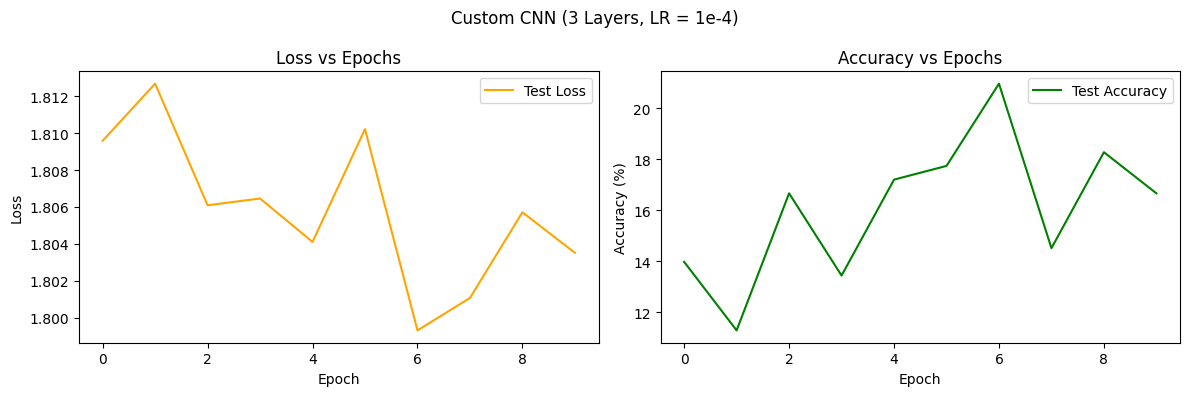

In [ ]:
# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(test_losses, label='Test Loss', color='orange')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss vs Epochs'); ax1.legend()

ax2.plot(test_accuracies, label='Test Accuracy', color='green')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy vs Epochs'); ax2.legend()

plt.suptitle('Custom CNN (3 Layers, LR = 1e-4)')
plt.tight_layout()
plt.show()

In [ ]:
# Predict some samples
categories = Train_d.classes
model.eval()

for idx in [0, 23, 42, 47, 500, 350, 400]:
    sample, label = Train_d[idx]
    with torch.no_grad():
        r = model(sample.unsqueeze(0).to(device))  # always 0
    print(f'Sample {idx} | Predicted: {categories[torch.argmax(r).item()]} | True label: {categories[label]}')

Sample 0 | Predicted: hungry | True label: belly_pain
Sample 23 | Predicted: belly_pain | True label: belly_pain
Sample 42 | Predicted: belly_pain | True label: belly_pain
Sample 47 | Predicted: belly_pain | True label: belly_pain
Sample 500 | Predicted: hungry | True label: tired
Sample 350 | Predicted: tired | True label: discomfort
Sample 400 | Predicted: hungry | True label: hungry
